# Automated Reliability Assessment Pipeline
### From Raw Failure Data to Actionable Metrics — at Scale

---

## Overview

In `01_tail_modeling.ipynb`, we established the statistical foundation: Weibull distributions, MLE instability at small n, and Bayesian regularization.

This notebook demonstrates the **engineering application**: a `ReliabilityReport` class that takes raw failure data and automatically produces:

- Best-fit distribution (selected by AIC)
- MTTF, B10, and B50 life estimates
- 4-panel diagnostic plot
- Plain-English failure mode interpretation
- **Batch mode**: assess an entire folder of components at once

The design goal is **scale and speed** — a reliability engineer should be able to drop in a CSV and get a complete assessment in seconds, without writing any analysis code themselves.

---

## Why Automate This?

A typical semiconductor equipment fleet might have hundreds of unique component types, each accumulating failure records over time. Manually fitting distributions and computing B-lives for each component is:
- Time-consuming
- Error-prone
- Inconsistent across analysts

An automated pipeline standardizes the methodology and makes reliability assessment a routine operation rather than a specialized task.

---

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import tempfile
import os
warnings.filterwarnings('ignore')

import sys
sys.path.append('../reliability')

from simulate import weibull_sample, censored_sample
from distributions import compare_distributions
from report import ReliabilityReport, batch_assess

print("Imports successful.")

Imports successful.


## Part 1: Single Component Assessment

Let's start with a realistic scenario: a component with **n=50 field failures**, known to follow a wear-out failure mode.

We simulate data from a Weibull(k=2.5, λ=1000) distribution — but in practice, you'd load this from a CSV of actual field records.

In [10]:
# Simulate realistic field data
np.random.seed(42)
TRUE_K, TRUE_LAM = 2.5, 1000.0
failure_data = weibull_sample(50, TRUE_K, TRUE_LAM, seed=42)

print(f"Sample of 50 failure times (hours):")
print(np.round(np.sort(failure_data), 1))

Sample of 50 failure times (hours):
[ 227.5  245.1  255.6  356.8  418.1  471.3  507.1  507.6  513.8  520.1
  542.9  565.7  574.8  580.   594.9  598.4  613.4  661.8  664.9  679.9
  680.5  693.7  720.3  732.6  809.5  887.9  894.1  897.   913.5  920.6
  925.3  927.   978.9  996.8  997.2 1014.6 1046.9 1062.5 1091.1 1170.3
 1170.8 1217.8 1225.8 1284.2 1311.  1330.2 1333.9 1410.4 1499.1 1578. ]


In [11]:
# Create and run the report
report = ReliabilityReport(failure_data, component_name="Optical Bearing — Unit A")
report.fit()
report.summary()

  RELIABILITY REPORT: Optical Bearing — Unit A
  Sample size       : 50 failures
  Best-fit model    : Weibull
  AIC               : 725.79
  KS p-value        : 0.8215

  --- Key Reliability Metrics ---
  MTTF (mean life)  :      838.0 hrs
  B10 life          :      410.0 hrs
  B50 life          :      822.9 hrs

  --- Weibull Parameters ---
  Shape k           : 2.704  95% CI [2.30, 3.36]
  Scale λ           : 942.3  95% CI [844, 1049]

  Failure mode      : wear-out failure (fatigue/degradation over time)

  --- Distribution Comparison ---
 rank distribution    aic    bic  ks_pvalue
    1      Weibull 725.79 729.62     0.8215
    2    Lognormal 731.64 735.46     0.3241
    3  Exponential 774.91 776.83     0.0000


### Interpreting the Output

A few things to note from the summary:

- **Weibull wins** (lowest AIC) — expected since we generated Weibull data
- **Exponential is rejected** (KS p-value ≈ 0) — the data clearly has increasing hazard rate, not constant
- **k > 1** confirms wear-out failure mode — hazard rate increases over time
- **B10 life** is the most operationally important metric — it's the warranty planning threshold

Now let's generate the 4-panel diagnostic plot:

Plot saved: ../reliability_report_demo.png


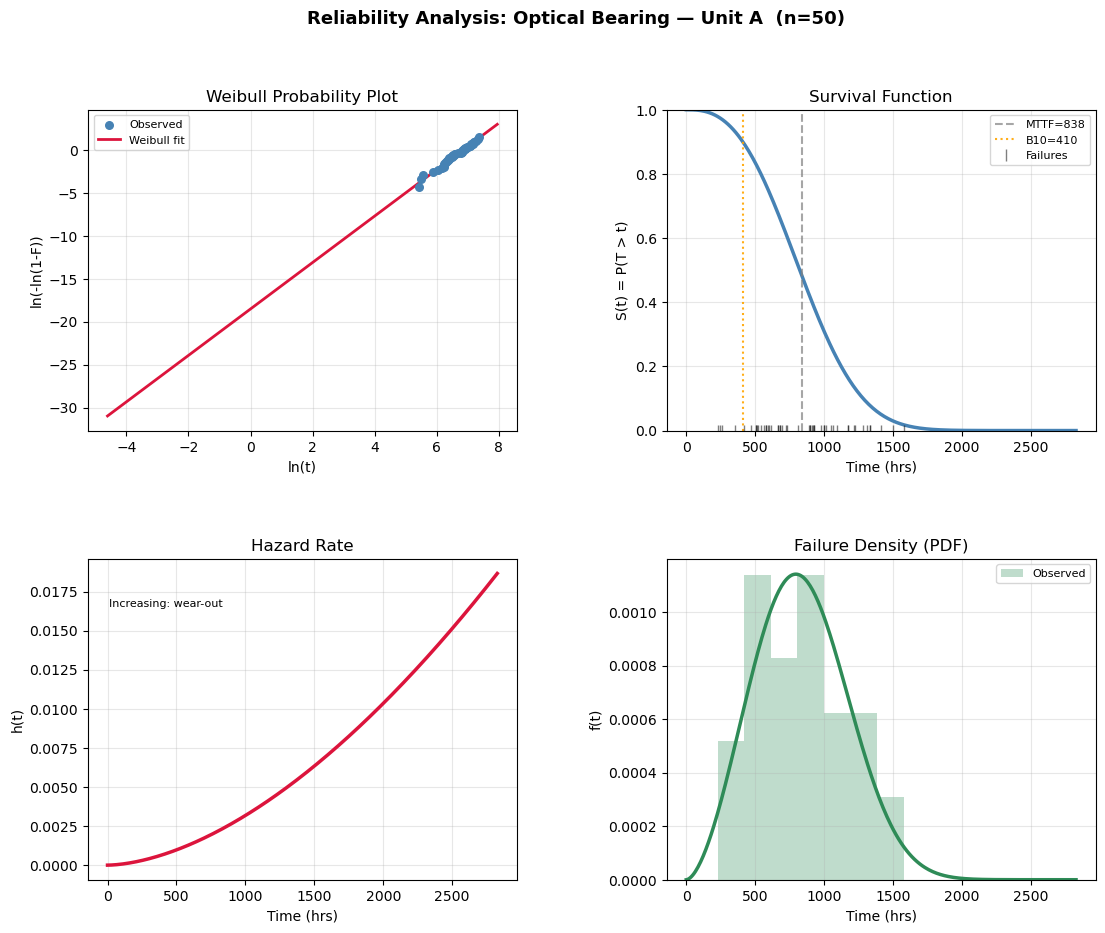

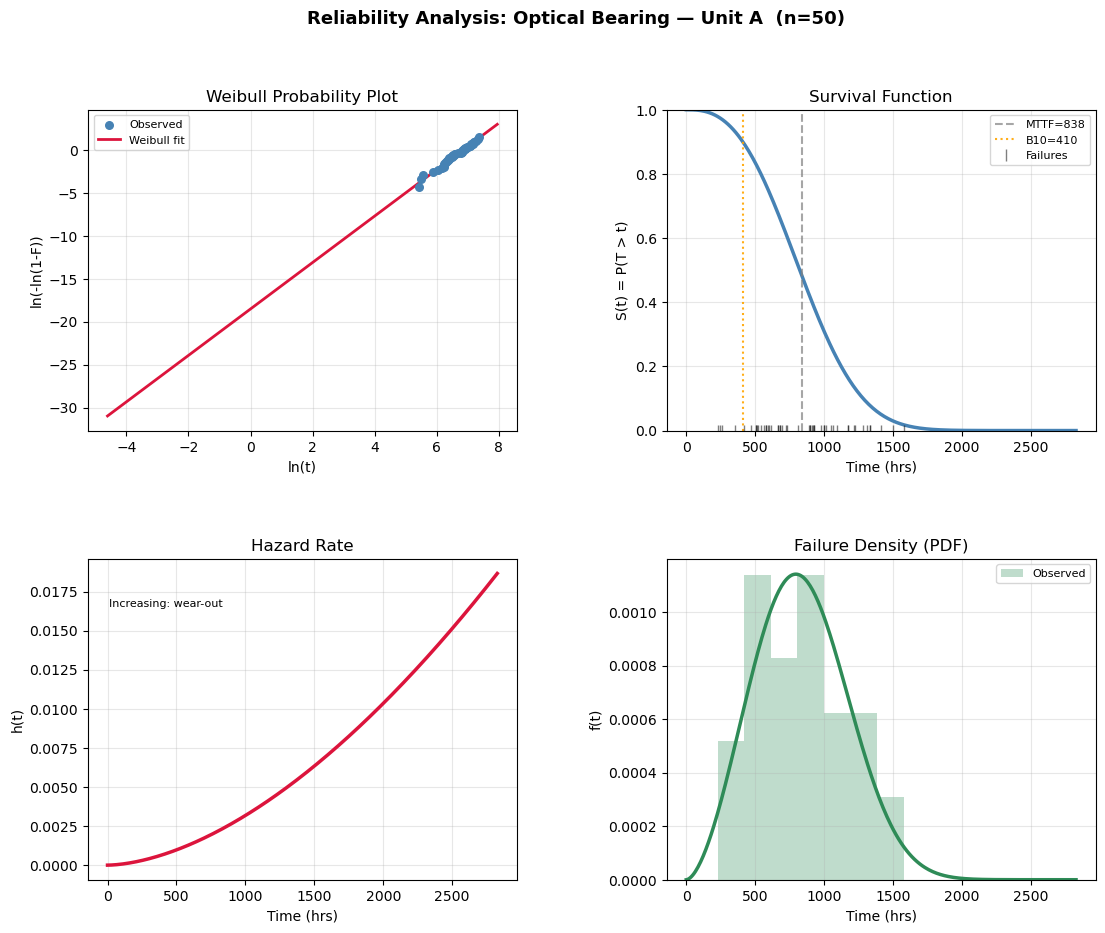

In [12]:
report.plot(save_path='../reliability_report_demo.png')

### Reading the 4-Panel Plot

**Top-left: Weibull Probability Plot**  
If the data truly follows a Weibull distribution, the points should fall on a straight line. Deviations suggest the model is a poor fit. This is the standard visual diagnostic used in reliability engineering.

**Top-right: Survival Function S(t)**  
Shows P(T > t) — the probability a unit is still operating at time t. The dashed lines mark MTTF and B10 life. The tick marks at the bottom show the actual observed failure times.

**Bottom-left: Hazard Rate h(t)**  
The instantaneous failure rate at time t. Increasing hazard = wear-out (k > 1). Flat = random failure (k = 1). Decreasing = infant mortality (k < 1). This is the "bathtub curve" in reliability engineering.

**Bottom-right: Failure Density PDF**  
The fitted distribution overlaid on a histogram of observed failures. A good fit means the curve tracks the histogram shape.

---

## Part 2: Loading Data from CSV

In practice, you'd load real field data from a CSV. Here's how that works:

In [13]:
# Save our simulated data to CSV and reload it — mirrors real usage
with tempfile.NamedTemporaryFile(mode='w', suffix='.csv', delete=False) as f:
    csv_path = f.name
    pd.DataFrame({
        'time_to_failure': failure_data,
        'unit_id': [f'SN-{i:04d}' for i in range(len(failure_data))],
        'failure_mode': 'wear'
    }).to_csv(f, index=False)

print(f"Saved to: {csv_path}")
print()

# Load from CSV — this is the intended production usage
report_from_csv = ReliabilityReport.from_csv(csv_path)
report_from_csv.fit()
report_from_csv.summary()

os.unlink(csv_path)  # cleanup

Saved to: /var/folders/9m/lrwb1sdd7838hlmbsg9xzky80000gn/T/tmp4h8gkwcx.csv

  RELIABILITY REPORT: tmp4h8gkwcx
  Sample size       : 50 failures
  Best-fit model    : Weibull
  AIC               : 725.79
  KS p-value        : 0.8215

  --- Key Reliability Metrics ---
  MTTF (mean life)  :      838.0 hrs
  B10 life          :      410.0 hrs
  B50 life          :      822.9 hrs

  --- Weibull Parameters ---
  Shape k           : 2.704  95% CI [2.30, 3.36]
  Scale λ           : 942.3  95% CI [844, 1049]

  Failure mode      : wear-out failure (fatigue/degradation over time)

  --- Distribution Comparison ---
 rank distribution    aic    bic  ks_pvalue
    1      Weibull 725.79 729.62     0.8215
    2    Lognormal 731.64 735.46     0.3241
    3  Exponential 774.91 776.83     0.0000


## Part 3: Comparing Failure Modes

Different components fail for different reasons. Let's run the report on three components with distinct failure modes and see how the tool correctly identifies each.

| Component | k | Failure Mode |
|-----------|---|-------------|
| Laser Module | 0.7 | Infant mortality — early defects |
| Sensor | 1.0 | Random failure — constant hazard |
| Bearing | 3.0 | Wear-out — fatigue over time |

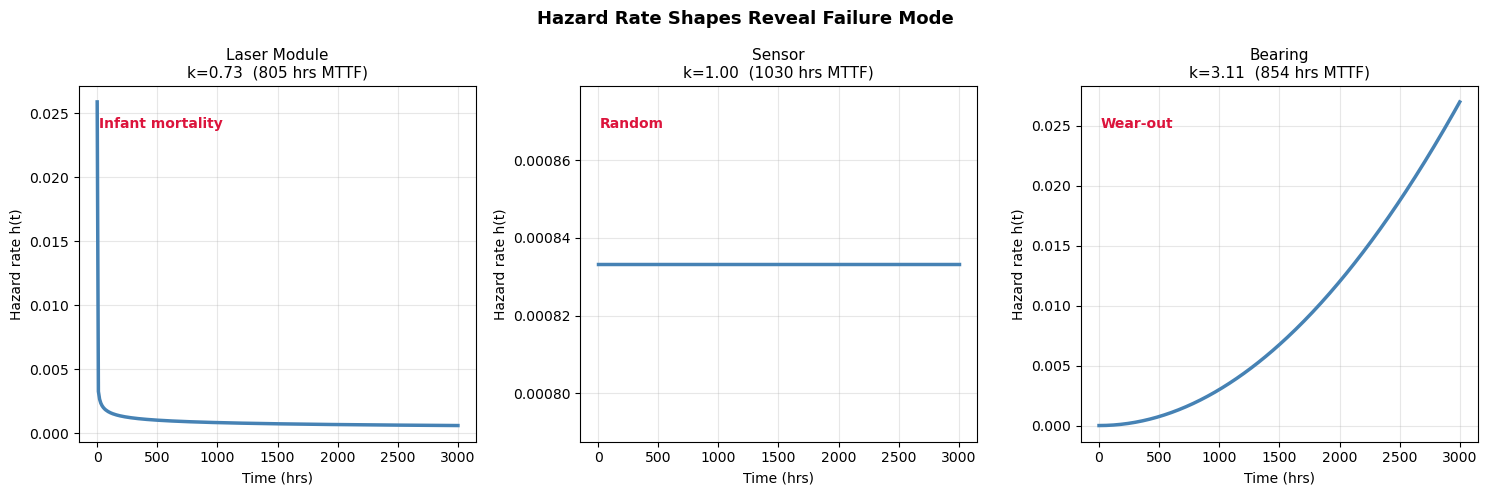

In [14]:
components = [
    ("Laser Module",  0.7, 800),
    ("Sensor",        1.0, 1200),
    ("Bearing",       3.0, 1000),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
t = np.linspace(0.01, 3000, 300)

for ax, (name, k, lam) in zip(axes, components):
    data = weibull_sample(40, k, lam, seed=42)
    r = ReliabilityReport(data, component_name=name)
    r.fit()
    
    # Plot hazard rate — this is what reveals the failure mode
    hazard = (k / lam) * (t / lam) ** (k - 1)
    ax.plot(t, hazard, lw=2.5, color='steelblue')
    ax.set_title(f"{name}\nk={r._best.get('k',1):.2f}  ({r.metrics['mttf']:.0f} hrs MTTF)",
                 fontsize=11)
    ax.set_xlabel('Time (hrs)')
    ax.set_ylabel('Hazard rate h(t)')
    ax.grid(alpha=0.3)
    
    mode = 'Infant mortality' if k < 1 else ('Random' if abs(k-1) < 0.15 else 'Wear-out')
    ax.annotate(mode, xy=(0.05, 0.88), xycoords='axes fraction',
                fontsize=10, color='crimson', fontweight='bold')

plt.suptitle('Hazard Rate Shapes Reveal Failure Mode', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../failure_modes_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Part 4: Batch Assessment

The real power of the pipeline is processing many components at once. The `batch_assess()` function takes a directory of CSV files and returns a summary DataFrame — one row per component.

This is the **"at scale"** requirement: a reliability engineer can drop a folder of field data exports and get a ranked summary of all components by MTTF, B10 life, and best-fit model.

In [15]:
# Generate a fleet of 8 synthetic components with varied failure modes
fleet = [
    ("bearing_primary",   2.5, 1000, 40),
    ("bearing_secondary", 2.8,  950, 35),
    ("laser_module",      0.7,  800, 25),
    ("optical_sensor",    1.1, 1500, 30),
    ("motor_drive",       3.2,  600, 45),
    ("cooling_fan",       1.8, 2000, 50),
    ("position_encoder", 2.0, 1200, 20),
    ("vacuum_pump",       1.5,  900, 38),
]

with tempfile.TemporaryDirectory() as tmpdir:
    # Write each component's data to a CSV
    for name, k, lam, n in fleet:
        data = weibull_sample(n, k, lam, seed=42)
        pd.DataFrame({'time_to_failure': data}).to_csv(
            f"{tmpdir}/{name}.csv", index=False
        )
    
    # Run batch assessment
    results = batch_assess(tmpdir)

# Sort by B10 life (most critical first)
results = results.sort_values('b10_life').reset_index(drop=True)
results.index += 1

print("Fleet Reliability Summary — Ranked by B10 Life (lowest = most urgent)")
print("=" * 75)
print(results.to_string())
print()
print(f"Most at-risk component : {results.iloc[0]['component']}  (B10={results.iloc[0]['b10_life']:.0f} hrs)")
print(f"Most reliable component: {results.iloc[-1]['component']}  (B10={results.iloc[-1]['b10_life']:.0f} hrs)")

Fleet Reliability Summary — Ranked by B10 Life (lowest = most urgent)
           component   n    best_dist     aic    mttf  b10_life  b50_life
1       laser_module  25      Weibull  365.66   595.1      15.3     258.3
2     optical_sensor  30  Exponential  488.12  1214.5     128.0     841.8
3        vacuum_pump  38      Weibull  572.53   733.2     185.6     639.6
4        motor_drive  45      Weibull  592.09   510.2     291.0     509.5
5   position_encoder  20      Weibull  305.59   931.9     342.8     876.1
6  bearing_secondary  35      Weibull  502.86   778.5     385.8     765.7
7    bearing_primary  40      Weibull  584.70   840.3     396.8     821.3
8        cooling_fan  50      Weibull  817.33  1633.0     579.7    1525.5

Most at-risk component : laser_module  (B10=15 hrs)
Most reliable component: cooling_fan  (B10=580 hrs)


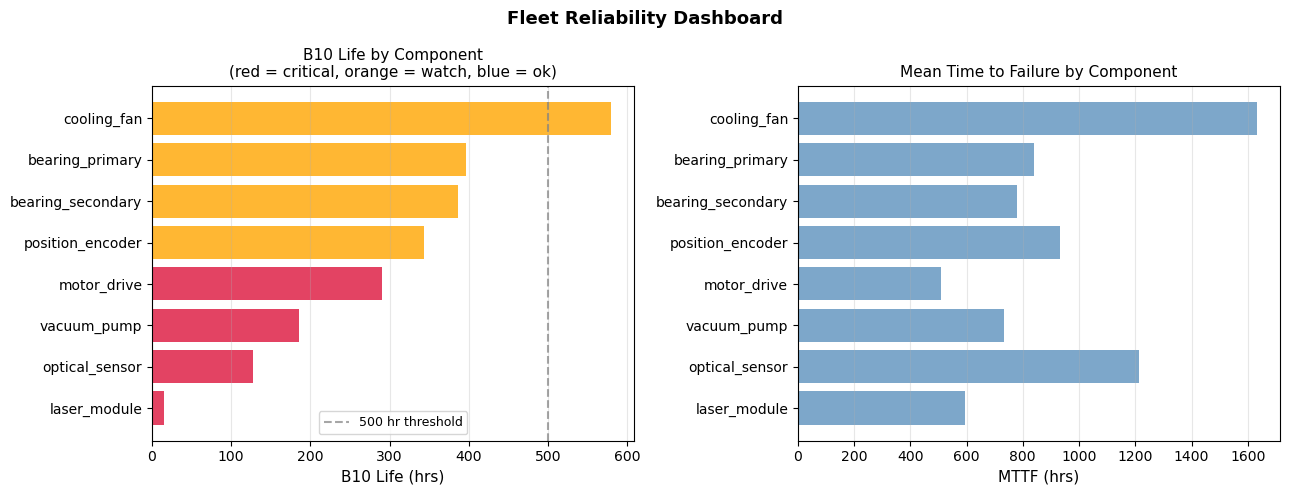

In [16]:
# Visualize the fleet summary
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# B10 life by component
ax = axes[0]
colors = ['crimson' if b < 300 else 'orange' if b < 600 else 'steelblue'
          for b in results['b10_life']]
bars = ax.barh(results['component'], results['b10_life'], color=colors, alpha=0.8)
ax.axvline(500, color='gray', linestyle='--', alpha=0.7, label='500 hr threshold')
ax.set_xlabel('B10 Life (hrs)', fontsize=11)
ax.set_title('B10 Life by Component\n(red = critical, orange = watch, blue = ok)',
             fontsize=11)
ax.legend(fontsize=9)
ax.grid(alpha=0.3, axis='x')

# MTTF by component
ax2 = axes[1]
ax2.barh(results['component'], results['mttf'], color='steelblue', alpha=0.7)
ax2.set_xlabel('MTTF (hrs)', fontsize=11)
ax2.set_title('Mean Time to Failure by Component', fontsize=11)
ax2.grid(alpha=0.3, axis='x')

plt.suptitle('Fleet Reliability Dashboard', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../fleet_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary & Next Steps

### What This Pipeline Delivers

| Capability | Implementation |
|------------|---------------|
| Auto distribution selection | AIC-ranked comparison of Weibull, Lognormal, Exponential |
| Key metrics | MTTF, B10, B50 life with confidence intervals |
| Visual diagnostics | Probability plot, survival function, hazard rate, PDF |
| Failure mode ID | Automatic interpretation of shape parameter k |
| Scale | Batch mode processes entire component fleet from CSV folder |
| CSV interface | `from_csv()` loader — no code changes needed for new data |

### Proposed Infrastructure Improvements

To deploy this in a production environment, the following additions would significantly improve accuracy and usability:

1. **Right-censoring support** — Current pipeline assumes all units have failed. Real field data has many units still running at observation time. Adding censored data handling (Nelson-Aalen estimator) would use all available information.

2. **AWS S3 integration** — Replace local CSV loading with S3 bucket polling. New failure records automatically trigger report regeneration.

3. **Hierarchical Bayesian model** — Instead of fitting each component independently, pool information across similar components. A bearing in tool A informs the prior for a bearing in tool B.

4. **Power BI / Streamlit dashboard** — Expose the batch results as an interactive dashboard so reliability engineers without Python experience can monitor fleet health.

5. **Alerting** — Flag components whose B10 life falls below a configurable threshold and trigger maintenance workflows.